In [1]:
import os
import sys
import warnings

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Ensure local imports work when running this notebook from data/scripts.
SCRIPT_DIR = os.path.dirname(os.path.abspath(""))
if SCRIPT_DIR not in sys.path:
    sys.path.append(SCRIPT_DIR)

from config import ANALYSIS_DATE, MAX_ELAPSED_MINUTES
from data_loader import (
    build_station_meta,
    derive_station_key,
    load_calendar,
    load_calendar_dates,
    load_routes,
    load_stop_times_basic,
    load_stop_times_hourly,
    load_stops,
    load_trips,
    services_active_on_date,
)
from data_downloader import (
    download_sbb_gtfs,
    download_swiss_boundary,
    download_vaud_boundary,
)
from reachability import (
    ReachabilityEngine,
    build_trip_graph,
    build_walking_neighbors,
    compute_active_rail_trips,
    compute_active_services,
    load_active_stop_times,
)
from spatial import filter_stops_within_vaud, load_vaud_boundary
from visualization import apply_mpl_defaults, plot_reachability_comparison_heatmap

apply_mpl_defaults()
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
print(f"Analysis date: {ANALYSIS_DATE.date()}")

Analysis date: 2026-03-18


## 0. Data downloading (optional)

If `data/raw_data/` is already prepared, you can skip this section.

This bus-focused notebook still uses the same GTFS source and adds the **Vaud canton boundary**.

In [2]:
# Uncomment if you need to (re)download GTFS and boundaries.
# download_sbb_gtfs()
# download_swiss_boundary()
# download_vaud_boundary()

print("Downloader calls are optional and commented by default.")

Downloader calls are optional and commented by default.


## 1. Load Stops & Basic Inspection (Vaud focus)

We start from all GTFS stops, then spatially filter to Vaud.

In [3]:
stops_df = load_stops()
print(f"Total stops in GTFS: {len(stops_df):,}")
display(stops_df.head(5))

Total stops in GTFS: 96,949


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code,original_stop_id
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,NaN,Parent1100008,NaN,ch:1:sloid:1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,NaN,Parent1100009,NaN,ch:1:sloid:1100009
2,1100010,Atzenbach,47.714618,7.872350,NaN,Parent1100010,NaN,ch:1:sloid:1100010
3,1100011,"Mambach, Brücke",47.728209,7.877470,NaN,Parent1100011,NaN,ch:1:sloid:1100011
4,1100012,"Mambach, Mühlschau",47.734082,7.881387,NaN,Parent1100012,NaN,ch:1:sloid:1100012


## 2. Spatial Filtering — Vaud Boundary

Use the local `vaud_boundary.geojson` to keep only stops physically located in Vaud.

Stops inside Vaud: 7,088


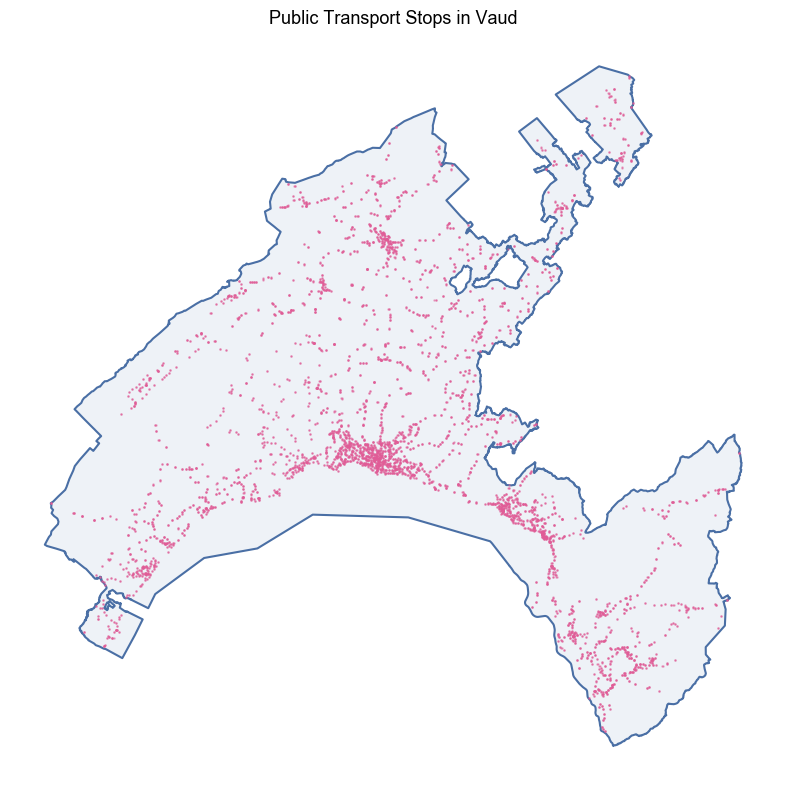

In [4]:
vaud_boundary_wgs84, vaud_boundary_proj = load_vaud_boundary()
vaud_stops_gdf = filter_stops_within_vaud(stops_df, vaud_boundary_wgs84)

print(f"Stops inside Vaud: {len(vaud_stops_gdf):,}")

# Quick map check
vaud_stops_proj = vaud_stops_gdf.to_crs("EPSG:2056")
fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
vaud_boundary_proj.plot(ax=ax, color="#eef2f7", edgecolor="#4a6fa5", linewidth=1.5)
vaud_stops_proj.plot(ax=ax, markersize=0.6, color="#e05c97", alpha=0.45)
ax.set_aspect("equal")
ax.set_title("Public Transport Stops in Vaud", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Bus Stop Extraction

Keep only stops that are served by bus trips.

Then apply a railway-style station deduplication step (`parent_station` fallback to `stop_id`) to build a logical bus-station table for analysis.

In [5]:
# GTFS bus route types:
# 3 = bus (standard GTFS)
# 700-716 = Swiss-specific bus/trolleybus related route classes
BUS_ROUTE_TYPES = [3] + list(range(700, 717))

routes_df = load_routes()
trips_df = load_trips()
stop_times_basic_df = load_stop_times_basic()

routes_df["route_id"] = routes_df["route_id"].astype(str)
trips_df["trip_id"] = trips_df["trip_id"].astype(str)
trips_df["route_id"] = trips_df["route_id"].astype(str)
stop_times_basic_df["trip_id"] = stop_times_basic_df["trip_id"].astype(str)
stop_times_basic_df["stop_id"] = stop_times_basic_df["stop_id"].astype(str)

bus_routes_df = routes_df[routes_df["route_type"].isin(BUS_ROUTE_TYPES)].copy()
bus_trips_df = trips_df[trips_df["route_id"].isin(bus_routes_df["route_id"])].copy()

bus_trip_ids = set(bus_trips_df["trip_id"].unique())
bus_stop_ids = set(
    stop_times_basic_df.loc[
        stop_times_basic_df["trip_id"].isin(bus_trip_ids), "stop_id"
    ].unique()
)

vaud_stops_df = vaud_stops_gdf.copy()
vaud_stops_df["stop_id"] = vaud_stops_df["stop_id"].astype(str)
vaud_bus_stops_df = vaud_stops_df[vaud_stops_df["stop_id"].isin(bus_stop_ids)].copy()

# 3a. Duplicate (platform-level) analysis
name_counts = (
    vaud_bus_stops_df.groupby("stop_name")
    .size()
    .sort_values(ascending=False)
    .rename("stop_count")
)

print("Top 10 Vaud bus stop names by number of GTFS stop entries:")
display(name_counts.head(10).reset_index())

# Deduplicate to logical station key (parent_station fallback to stop_id)
vaud_bus_stops_df["station_key"] = derive_station_key(vaud_bus_stops_df)
vaud_bus_meta = build_station_meta(vaud_bus_stops_df)

print(f"Bus routes in feed: {len(bus_routes_df):,}")
print(f"Bus trips in feed: {len(bus_trips_df):,}")
print(f"Vaud bus stop entries (raw): {len(vaud_bus_stops_df):,}")
print(f"Vaud logical bus stations (deduplicated): {len(vaud_bus_meta):,}")
print(f"Deduplicated entries: {len(vaud_bus_stops_df) - len(vaud_bus_meta):,}")
display(vaud_bus_meta.head(10))

Top 10 Vaud bus stop names by number of GTFS stop entries:


,stop_name,stop_count
0,"Yverdon-les-Bains, gare",7
1,"Lausanne, gare",7
2,"Villeneuve VD, gare",6
3,"Aigle, gare",6
4,"Renens VD, gare",6
5,"Lausanne, Georgette",6
6,"Epalinges, Croisettes",6
7,"Vevey, gare",5
8,"Mézières VD, station",5
9,"Lausanne, Tunnel",5


Bus routes in feed: 3,509
Bus trips in feed: 772,768
Vaud bus stop entries (raw): 3,992
Vaud logical bus stations (deduplicated): 2,208
Deduplicated entries: 1,784


,station_key,station_name,stop_lat,stop_lon
0,Parent8570093,"Aclens, collège",46.567231,6.510288
1,Parent8570235,"Agiez, L'Epine",46.715787,6.507836
2,Parent8507650,"Agiez, Vers-le-Pont",46.719032,6.511106
3,Parent8505195,"Aigle, Artisans",46.314766,6.939306
4,Parent8505193,"Aigle, Biole",46.309920,6.945226
5,Parent8593765,"Aigle, Champex",46.311782,6.943474
6,Parent8504420,"Aigle, Charmettes",46.310100,6.963920
7,Parent8593766,"Aigle, Dents-du-Midi",46.313786,6.959213
8,Parent8581048,"Aigle, Golf",46.315368,6.949089
9,Parent8504407,"Aigle, Grand-Pré",46.316553,6.937680


## 4. Busiest Bus Stations (interactive)

This chart counts unique active bus `trip_id`s per **logical station** in Vaud on `ANALYSIS_DATE`.

Aggregation is based on station deduplication (`parent_station` fallback to `stop_id`), not the raw row count of `stop_times.txt`.

In [6]:
calendar_df = load_calendar()
calendar_dates_df = load_calendar_dates()
active_services = services_active_on_date(calendar_df, calendar_dates_df, ANALYSIS_DATE)

active_bus_trips_df = bus_trips_df[bus_trips_df["service_id"].isin(active_services)].copy()
active_bus_trip_ids = set(active_bus_trips_df["trip_id"].astype(str).unique())
vaud_bus_stop_ids = set(vaud_bus_stops_df["stop_id"].astype(str).unique())

stop_times_windowed = load_stop_times_hourly(
    trip_ids=active_bus_trip_ids,
    stop_ids=vaud_bus_stop_ids,
)

# Map each stop_id to logical station_key for deduplicated aggregation.
stop_to_station = vaud_bus_stops_df[["stop_id", "station_key"]].drop_duplicates("stop_id")
stop_times_windowed = stop_times_windowed.merge(stop_to_station, on="stop_id", how="left")
stop_times_windowed = stop_times_windowed.dropna(subset=["station_key"])

station_name_lookup = vaud_bus_meta.set_index("station_key")["station_name"].to_dict()

print(f"Date: {ANALYSIS_DATE.date()} | Active bus services: {len(active_services):,}")
print(f"Active bus trips: {len(active_bus_trip_ids):,} | Vaud bus stop-time records: {len(stop_times_windowed):,}")
print("Metric: unique active bus trips per logical station in the selected minute-level window.")

busiest_start_slider = widgets.IntSlider(
    value=6 * 60,
    min=0,
    max=23 * 60 + 59,
    step=10,
    description="Start",
    continuous_update=False,
)
busiest_end_slider = widgets.IntSlider(
    value=10 * 60,
    min=0,
    max=23 * 60 + 59,
    step=10,
    description="End",
    continuous_update=False,
)
busiest_window_label = widgets.HTML()
busiest_output = widgets.Output()


def _clock(m: int) -> str:
    return f"{(m // 60) % 24:02d}:{m % 60:02d}"


def update_busiest_bus(*_):
    start = int(busiest_start_slider.value)
    end = int(busiest_end_slider.value)
    if start >= end:
        busiest_window_label.value = "<b style='color:#a00;'>Start must be earlier than End.</b>"
        with busiest_output:
            busiest_output.clear_output(wait=True)
            print("Invalid time window.")
        return

    busiest_window_label.value = (
        f"<b>Window:</b> {_clock(start)} - {_clock(end)}"
    )

    mask = (
        (stop_times_windowed["departure_minutes"] >= start)
        & (stop_times_windowed["departure_minutes"] < end)
    )
    busiest = (
        stop_times_windowed.loc[mask]
        .groupby("station_key")["trip_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(10)
    )

    with busiest_output:
        busiest_output.clear_output(wait=True)
        if busiest.empty:
            print("No active bus trips in this window.")
            return

        labels = [station_name_lookup.get(k, k) for k in busiest.index]
        # Keep the same color logic as rail busiest-stops plot.
        vmin, vmax = busiest.values.min(), busiest.values.max()
        normed = (busiest.values - vmin) / max(vmax - vmin, 1)
        cmap = plt.colormaps["YlOrRd"]
        colors = [cmap(0.25 + 0.7 * v) for v in normed]

        fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")
        ax.barh(labels, busiest.values, color=colors, edgecolor="white", linewidth=0.5)
        ax.invert_yaxis()
        ax.set_xlabel("Unique bus trips")
        ax.set_title(
            f"Top 10 Busiest Bus Stations ({_clock(start)} - {_clock(end)})",
            fontsize=13,
            fontweight="bold",
        )
        ax.xaxis.grid(True, alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()


busiest_start_slider.observe(update_busiest_bus, names="value")
busiest_end_slider.observe(update_busiest_bus, names="value")


display(
    widgets.VBox([
        widgets.HBox([busiest_start_slider, busiest_end_slider]),
        busiest_window_label,
        busiest_output,
    ])
)
update_busiest_bus()

Date: 2026-03-18 | Active bus services: 6,992
Active bus trips: 152,906 | Vaud bus stop-time records: 239,200
Metric: unique active bus trips per logical station in the selected minute-level window.


## 5. Reachability Analysis (Vaud bus, from Lausanne, Bel-Air)

Build a time-expanded graph from active bus trips, then compute earliest-arrival reachability from a selected origin.

In [7]:
active_offsets_df = compute_active_services(
    calendar_df,
    calendar_dates_df,
    ANALYSIS_DATE,
    MAX_ELAPSED_MINUTES,
)

active_bus_graph_df = compute_active_rail_trips(bus_trips_df, active_offsets_df)
active_bus_graph_df = active_bus_graph_df.merge(
    bus_routes_df[["route_id", "route_short_name", "route_desc"]],
    on="route_id",
    how="left",
)

# Use the same logical station_key strategy as rail EDA.
stops_all_df = stops_df.copy()
stops_all_df["stop_id"] = stops_all_df["stop_id"].astype(str)
stops_all_df["station_key"] = derive_station_key(stops_all_df)

active_stop_times_df = load_active_stop_times(
    active_trip_ids=set(active_bus_graph_df["trip_id"].astype(str).unique()),
    swiss_train_stop_ids=set(vaud_bus_stops_df["stop_id"].astype(str).unique()),
    stops_all_df=stops_all_df,
    active_rail_df=active_bus_graph_df,
)

trip_instances, departures_by_station, departure_times_by_station = build_trip_graph(active_stop_times_df)

# Walking model: allow short transfers between nearby bus stations.
# Typical adult walking speed is about 5 km/h.
WALKING_SPEED_KMH = 5.0
MAX_WALK_MINUTES = 120000000.0
walking_neighbors = build_walking_neighbors(
    vaud_bus_meta,
    max_walk_minutes=MAX_WALK_MINUTES,
    walking_speed_kmh=WALKING_SPEED_KMH,
)

# Bus notebook uses a local origin setting so railway config is unaffected.
BUS_START_STATION_NAME = "Lausanne, Bel-Air"

# Try exact station name first; fallback to partial match.
origin_candidates = vaud_bus_meta[
    vaud_bus_meta["station_name"].str.casefold() == BUS_START_STATION_NAME.casefold()
]
if origin_candidates.empty:
    origin_candidates = vaud_bus_meta[
        vaud_bus_meta["station_name"].str.contains(BUS_START_STATION_NAME, case=False, na=False)
    ]
if origin_candidates.empty:
    raise ValueError(f"Origin not found in Vaud bus stops: {BUS_START_STATION_NAME}")

start_station_row = origin_candidates.iloc[0]
start_station_key = start_station_row["station_key"]

engine_transit_only = ReachabilityEngine(
    swiss_train_meta=vaud_bus_meta,
    trip_instances=trip_instances,
    departures_by_station=departures_by_station,
    departure_times_by_station=departure_times_by_station,
    start_station_key=start_station_key,
)
engine_with_walking = ReachabilityEngine(
    swiss_train_meta=vaud_bus_meta,
    trip_instances=trip_instances,
    departures_by_station=departures_by_station,
    departure_times_by_station=departure_times_by_station,
    start_station_key=start_station_key,
    walking_neighbors=walking_neighbors,
)

# Default mode for this notebook section: include walking.
engine = engine_with_walking

walk_edges = sum(len(v) for v in walking_neighbors.values()) // 2
print(f"Graph trip instances: {len(trip_instances):,}")
print(f"Departure nodes: {sum(len(v) for v in departures_by_station.values()):,}")
print(f"Walking edges (<= {MAX_WALK_MINUTES:.0f} min): {walk_edges:,} @ {WALKING_SPEED_KMH:.1f} km/h")
print(f"Origin used: {start_station_row['station_name']} ({start_station_key})")

Graph trip instances: 43,585
Departure nodes: 674,899
Walking edges (<= 120000000 min): 2,436,528 @ 5.0 km/h
Origin used: Lausanne, Bel-Air (Parent8591988)


In [8]:
def plot_vaud_bus_reachability(
    reachable_frame: pd.DataFrame,
    bus_meta: pd.DataFrame,
    start_row: pd.Series,
    boundary_proj: gpd.GeoDataFrame,
    departure_minutes: int,
    elapsed_minutes: int,
    origin_label: str,
):
    stations_gdf = gpd.GeoDataFrame(
        bus_meta,
        geometry=gpd.points_from_xy(bus_meta["stop_lon"], bus_meta["stop_lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:2056")

    merged = stations_gdf.merge(
        reachable_frame[["station_key", "reachable", "travel_minutes"]],
        on="station_key",
        how="left",
    )

    unreachable = merged[~merged["reachable"].fillna(False)]
    reachable = merged[merged["reachable"].fillna(False)]

    start_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([start_row["stop_lon"]], [start_row["stop_lat"]]),
        crs="EPSG:4326",
    ).to_crs("EPSG:2056")

    minx, miny, maxx, maxy = boundary_proj.total_bounds
    x_pad, y_pad = (maxx - minx) * 0.04, (maxy - miny) * 0.04

    fig, ax = plt.subplots(figsize=(12, 9), dpi=130, facecolor="white")
    boundary_proj.plot(ax=ax, color="#f0f4f8", edgecolor="#4a6fa5", linewidth=1.2)

    ax.scatter(
        unreachable.geometry.x,
        unreachable.geometry.y,
        s=5,
        color="#cfd8dc",
        alpha=0.55,
        label="Not reachable",
        zorder=2,
    )

    if not reachable.empty:
        scatter = ax.scatter(
            reachable.geometry.x,
            reachable.geometry.y,
            c=reachable["travel_minutes"],
            s=18,
            cmap="plasma_r",
            vmin=0,
            vmax=elapsed_minutes,
            alpha=0.92,
            label="Reachable stops",
            zorder=3,
        )
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.78, pad=0.02)
        cbar.set_label("Travel time (minutes)")

    ax.scatter(
        [start_gdf.geometry.x.values[0]],
        [start_gdf.geometry.y.values[0]],
        color="#d62728",
        s=260,
        marker="*",
        label=origin_label,
        zorder=5,
    )

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    ax.set_aspect("equal")
    ax.set_title(
        f"Vaud Bus Reachability from {origin_label}\n"
        f"Departure {(departure_minutes // 60) % 24:02d}:{departure_minutes % 60:02d} | "
        f"Window {elapsed_minutes} min",
        fontsize=13,
        fontweight="bold",
    )
    ax.axis("off")
    ax.legend(loc="lower left", framealpha=0.9)
    plt.tight_layout()
    plt.show()


departure_slider = widgets.IntSlider(
    value=8 * 60,
    min=0,
    max=23 * 60 + 59,
    step=10,
    description="Depart",
    continuous_update=False,
)
elapsed_slider = widgets.IntSlider(
    value=120,
    min=30,
    max=1000,
    step=10,
    description="Window",
    continuous_update=False,
)
walking_checkbox = widgets.Checkbox(
    value=True,
    description="Include walking links",
)

reachability_label = widgets.HTML()
reachability_output = widgets.Output()


def _selected_engine():
    return engine_with_walking if walking_checkbox.value else engine_transit_only


def update_reachability(*_):
    dep = int(departure_slider.value)
    elapsed = int(elapsed_slider.value)

    rf = _selected_engine().build_reachable_frame(dep, elapsed)
    reachable_count = int(rf["reachable"].fillna(False).sum())
    total = len(rf)
    mode = "Transit + walking" if walking_checkbox.value else "Transit only"

    reachability_label.value = (
        f"<b>Departure:</b> {(dep // 60) % 24:02d}:{dep % 60:02d} "
        f"| <b>Window:</b> {elapsed} min "
        f"| <b>Mode:</b> {mode} "
        f"| <b>Reachable:</b> {reachable_count}/{total} ({reachable_count / max(total, 1):.1%})"
    )

    with reachability_output:
        reachability_output.clear_output(wait=True)
        plot_vaud_bus_reachability(
            reachable_frame=rf,
            bus_meta=vaud_bus_meta,
            start_row=start_station_row,
            boundary_proj=vaud_boundary_proj,
            departure_minutes=dep,
            elapsed_minutes=elapsed,
            origin_label=start_station_row["station_name"],
        )


departure_slider.observe(update_reachability, names="value")
elapsed_slider.observe(update_reachability, names="value")
walking_checkbox.observe(update_reachability, names="value")

display(
    widgets.VBox([
        widgets.HBox([departure_slider, elapsed_slider]),
        walking_checkbox,
        reachability_label,
        reachability_output,
    ])
)
update_reachability()

## 6. Scope, Assumptions, and Milestone 1 Positioning

For Milestone 1 in this bus-focused variant, the analysis is restricted to **Vaud bus accessibility** (not nationwide multimodal routing).

- Included in the current analysis: Vaud bus logical stations (`route_type` 3 and 700-716), timetable-based reachability, station-level aggregation via `parent_station` fallback, and nearby-station walking links based on geodesic distance and assumed walking speed.
- Excluded from the current analysis: rail/tram/cable car integration, detailed walking transfer modeling, cross-canton continuation, and full itinerary reconstruction.
- Rationale for the selected scope: consistent with the existing GTFS time-expanded graph pipeline, manageable preprocessing cost, and clear validation of the visualization/interaction workflow.

The notebook therefore serves as a feasibility study for **Vaud bus-first accessibility visualization**, while broader multimodal planning remains outside Milestone 1 scope.

Reachable station count table (within 60 minutes):


departure_label,06:00,08:00,12:00,18:00
origin,,,,
"Lausanne, Bel-Air",577,549,520,561
"Renens VD, gare",537,508,496,505
"Vevey, gare",226,225,218,237
"Yverdon-les-Bains, gare",331,322,311,329


Reachable station share table:


departure_label,06:00,08:00,12:00,18:00
origin,,,,
"Lausanne, Bel-Air",26.1%,24.9%,23.6%,25.4%
"Renens VD, gare",24.3%,23.0%,22.5%,22.9%
"Vevey, gare",10.2%,10.2%,9.9%,10.7%
"Yverdon-les-Bains, gare",15.0%,14.6%,14.1%,14.9%


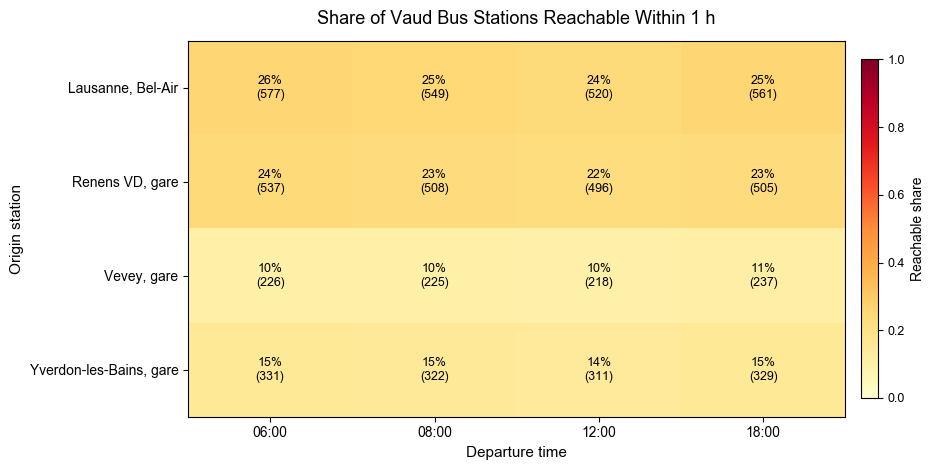

Comparison mode: Transit + walking
Highest reachability share: Lausanne, Bel-Air at 06:00 (26.1%, 577 stations)


In [9]:
comparison_origin_queries = [
    "Lausanne, Bel-Air",
    "Renens VD, gare",
    "Yverdon-les-Bains, gare",
    "Vevey, gare",
]
comparison_departures = [6 * 60, 8 * 60, 12 * 60, 18 * 60]
comparison_horizon_minutes = 1 * 60
comparison_include_walking = True
comparison_rows = []


def resolve_bus_origin(meta: pd.DataFrame, query: str) -> tuple[str, str]:
    exact = meta[meta["station_name"].str.casefold() == query.casefold()]
    if not exact.empty:
        row = exact.iloc[0]
        return row["station_key"], row["station_name"]

    fuzzy = meta[meta["station_name"].str.contains(query, case=False, na=False)]
    if not fuzzy.empty:
        row = fuzzy.iloc[0]
        return row["station_key"], row["station_name"]

    raise ValueError(f"Origin query not found in Vaud bus stations: {query}")


for origin_query in comparison_origin_queries:
    origin_key, origin_label = resolve_bus_origin(vaud_bus_meta, origin_query)
    origin_engine = ReachabilityEngine(
        vaud_bus_meta,
        trip_instances,
        departures_by_station,
        departure_times_by_station,
        origin_key,
        walking_neighbors=walking_neighbors if comparison_include_walking else None,
    )

    for dep_minutes in comparison_departures:
        origin_rf = origin_engine.build_reachable_frame(dep_minutes, comparison_horizon_minutes)
        reachable_count = int(origin_rf["reachable"].fillna(False).sum())
        comparison_rows.append(
            {
                "origin": origin_label,
                "departure_minutes": dep_minutes,
                "departure_label": f"{dep_minutes // 60:02d}:00",
                "reachable_count": reachable_count,
                "reachable_share": reachable_count / len(vaud_bus_meta),
            }
        )

comparison_df = pd.DataFrame(comparison_rows)

# Railway notebook-like table style: origin rows x departure columns.
departure_order = [f"{m // 60:02d}:00" for m in comparison_departures]
comparison_count_table = (
    comparison_df.pivot(index="origin", columns="departure_label", values="reachable_count")
    .reindex(columns=departure_order)
    .astype(int)
)
comparison_share_table = (
    comparison_df.pivot(index="origin", columns="departure_label", values="reachable_share")
    .reindex(columns=departure_order)
)

print(f"Reachable station count table (within {comparison_horizon_minutes} minutes):")
display(comparison_count_table)

print("Reachable station share table:")
display(comparison_share_table.style.format("{:.1%}"))

plot_reachability_comparison_heatmap(
    comparison_df,
    value_col="reachable_share",
    horizon_minutes=comparison_horizon_minutes,
    title_prefix="Share of Vaud Bus Stations Reachable",
)

mode_text = "Transit + walking" if comparison_include_walking else "Transit only"
print(f"Comparison mode: {mode_text}")

best_row = comparison_df.sort_values("reachable_share", ascending=False).iloc[0]
print(
    f"Highest reachability share: {best_row['origin']} at {best_row['departure_label']} "
    f"({best_row['reachable_share']:.1%}, {int(best_row['reachable_count'])} stations)"
)

### Interpretation

This comparison helps assess temporal and spatial sensitivity of Vaud bus accessibility: some origins and departure windows consistently reach a larger share of logical stations, while peripheral origins show lower coverage under the same horizon.